<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/GrdientDescentT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 옵티마이저별 수식 요약

#### 1. AdaGrad
$$\theta_{new} = \theta_{old} - \frac{1}{\sqrt{\Sigma g^2 + \epsilon}}\cdot\eta \cdot g$$

#### 2. Momentum
$$v_{new} = \beta v_{old} + \eta \nabla J(\theta)$$
$$\theta_{new} = \theta_{old} - v_{new}$$

#### 3. Nesterov Accelerated Gradient (NAG)
$$v_t = \beta v_{t-1} + \eta \nabla J(\theta_{t-1} - \beta v_{t-1})$$
$$\theta_{t} = \theta_{t-1} - v_t$$

#### 4. RMSprop
$$s_t = \beta_2 s_{t-1} + (1 - \beta_2) g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{1}{\sqrt{s_t} + \epsilon}\cdot \eta \cdot g_t$$

#### 5. Adam (Adaptive Moment Estimation)
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1 - \beta_1^t)$$
$$\hat{v}_t = v_t / (1 - \beta_2^t)$$
$$\theta_{t} = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

#### 6. Nadam (Nesterov-accelerated Adaptive Moment Estimation)
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1 - \beta_1^t)$$
$$\hat{v}_t = v_t / (1 - \beta_2^t)$$
$$m_{nesterov} = \beta_1 \hat{m}_t + (1 - \beta_1) g_t / (1 - \beta_1^t)$$
$$\theta_{new} = \theta_{old} - \eta \frac{m_{nesterov}}{\sqrt{\hat{v}_t} + \epsilon}$$

#### 7. AdamW (Adam with decoupled Weight decay)
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1 - \beta_1^t)$$
$$\hat{v}_t = v_t / (1 - \beta_2^t)$$
$$\theta_{temp} = \theta_{old} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$
$$\theta_{new} = \theta_{temp} - \eta \lambda \theta_{old}$$

#### 8. NadamW (Nadam + AdamW 결합)
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1 - \beta_1^t)$$
$$\hat{v}_t = v_t / (1 - \beta_2^t)$$
$$m_{nesterov} = \beta_1 \hat{m}_t + (1 - \beta_1) g_t / (1 - \beta_1^t)$$
$$\theta_{temp} = \theta_{old} - \eta \frac{m_{nesterov}}{\sqrt{\hat{v}_t} + \epsilon}$$
$$\theta_{new} = \theta_{temp} - \eta \lambda \theta_{old}$$

In [1]:
# Optimizer ------------------------------------------- 0 <GrdientDescentT.ipynb>

import numpy as np
import matplotlib.pyplot as plt

def func(x):                               # 입력 x 를 받는 함수
  return x**2                              # 2차 함수 f(x) = x^2

def grad_func(x):
  return 2*x                               # 함수 f(x)의 미분 함수 f'(x) = 2*x

x_line = np.linspace(-6, 6, 100)           # 정의역(domain) -6 부터 +6 까지 100 개의 점
y_line = func(x_line)                      # y = f(x) 함수 계산, 100 개의 y 값

# 그래프 -----------------------------------------------------------------------
def graph(paths_x, optimizer, title, paths_lookahead=None, direction=None):

  # 함수 그래프 y = x**2
  plt.plot(x_line, y_line, 'k-', label='f(x)')
  # x 시작 위치
  plt.plot(paths_x[0], func(paths_x[0]), 'ks', markersize=14,
           markeredgewidth=2, markerfacecolor='none')
  # 현재 경로 그래프 (x_current)
  if direction is None:
   direction = []
   for i in paths_x:
     direction.append(grad_func(i))        # 기울기로 방향 판단(+:왼쪽 -:오른쪽)

  d = zip(paths_x, direction)
  for i, (x, s) in enumerate(d):
    if s >= 0.0:   # 이동 방향이 왼쪽
      plt.plot(x, func(x), 'ro:', markersize=6, markeredgewidth=1, markerfacecolor='none')
      if i == 0: continue
      plt.text(x-0.1, func(x)-2, f'${i}$', verticalalignment='center', color='red')
    else:          # 이동 방향이 오른쪽
      plt.plot(x, func(x), 'gs:', markersize=6, markeredgewidth=1, markerfacecolor='none')
      if i == 0: continue
      plt.text(x-0.15, func(x)+2, f'${i}$', verticalalignment='center', color='green')
  # 최종 위치
  plt.plot(paths_x[-1], func(paths_x[-1]), 'ko', markersize=22,
           markeredgewidth=2, markerfacecolor='none')
  # 학습회수
  plt.text(-1, 20, f"{len(paths_x)-1}", fontdict={'size': 64})

  # x_lookahead ----------------------------------------------------------------
  if paths_lookahead is not None:                 # lookahead 경로 그래프
    plt.plot(paths_lookahead, func(paths_lookahead), 'b^:', markersize=10,
             markeredgewidth=1, markerfacecolor='none',
             label='Lookahead Path')
    for k, point in enumerate(paths_lookahead):   # 위치 번호 표시 (x_lookahead)
          if k == 0: continue
          plt.text(point-0.15, func(point)+4, f"${k}$", verticalalignment='center',
                   color='blue')
  if paths_lookahead is not None:                 # lookahead 최종 위치
    plt.plot(paths_lookahead[-1], func(paths_lookahead[-1]), 'bs', markersize=14,
                markeredgewidth=2, markerfacecolor='none')
  # 범례 표시
  plt.legend()
  plt.grid()
  plt.xlabel('X')
  plt.ylabel('f(x)')
  plt.title(optimizer+'   '+title)
  plt.savefig(f'{optimizer}_{len(paths_x)-1:04d}.png')
  plt.show()


### 1. Gradient Descent (경사 하강법)

가장 기본적인 최적화 알고리즘으로, 비용 함수의 기울기를 따라 파라미터를 점진적으로 조정합니다. 모든 학습 데이터에 대한 기울기를 계산하여 업데이트하기 때문에 데이터셋이 큰 경우 비효율적일 수 있습니다.
$$ g = \nabla J(\theta_{old}) $$
$$\theta_{new} = \theta_{old} - \eta \cdot g$$
$$ $$
$$\eta:Learn~Rate$$

- **장점**: 개념적 단순성, 구현 용이성.
- **단점**: 학습률 선택의 중요성, 지역 최적점 문제, 대규모 데이터셋에서 느린 수렴 속도.

Ep       x      f(x)       g
    5.80000 33.64000 11.60000
------------------------------
 1  5.22000 27.24840 10.44000
 2  4.69800 22.07120  9.39600
 3  4.22820 17.87768  8.45640
 4  3.80538 14.48092  7.61076
 5  3.42484 11.72954  6.84968
 6  3.08236  9.50093  6.16472
 7  2.77412  7.69575  5.54824
 8  2.49671  6.23356  4.99342
 9  2.24704  5.04918  4.49408
10  2.02233  4.08984  4.04467
11  1.82010  3.31277  3.64020
12  1.63809  2.68334  3.27618
13  1.47428  2.17351  2.94856
14  1.32685  1.76054  2.65371
15  1.19417  1.42604  2.38834
16  1.07475  1.15509  2.14950
17  0.96728  0.93562  1.93455
18  0.87055  0.75786  1.74110
19  0.78349  0.61386  1.56699
20  0.70514  0.49723  1.41029
21  0.63463  0.40276  1.26926
22  0.57117  0.32623  1.14233
23  0.51405  0.26425  1.02810
24  0.46265  0.21404  0.92529
25  0.41638  0.17337  0.83276
26  0.37474  0.14043  0.74949
27  0.33727  0.11375  0.67454
28  0.30354  0.09214  0.60708
29  0.27319  0.07463  0.54637
30  0.24587  0.06045  0.49174
31  0.2212

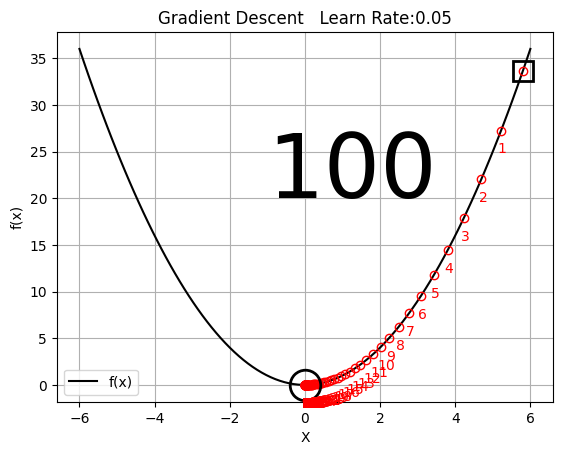

In [4]:
# Gradient Descent ------------------------------------ 1 <GrdientDescentT.ipynb>

START = 5.8                                         # 시작 x
LEARNING_RATE = 0.05                                # 학습율
EPOCHS = 100                                        # 학습 회수

x = START
paths = [x,]                                        # x 위치 데이터

print("="*30)
print('Ep       x      f(x)       g')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f}')
print("-"*30)

# ------------------------------------------------------------------------------
for epoch in range(EPOCHS):

  g = grad_func(x)             # 기울기 f'(x_old), g의 부호-> +:왼쪽, -:오른쪽
  x = x - LEARNING_RATE * g

  paths.append(x)

  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f}')

graph(np.array(paths), 'Gradient Descent', f'Learn Rate:{LEARNING_RATE}')

### 2. Momentum (모멘텀)

경사 하강법에 '관성'의 개념을 도입한 옵티마이저입니다. 이전 업데이트 방향을 일정 부분 유지하면서 현재 기울기 방향으로 이동합니다. 이를 통해 지역 최적점에 갇히는 것을 방지하고, 최적화 과정에서 발생하는 불필요한 진동을 줄여 수렴 속도를 향상시킵니다.

$$v_{new} = \beta v_{old} + \eta \nabla J(\theta)$$
$$\theta_{new} = \theta_{old} - v_{new}$$
$$ $$
$$\eta:Learn~Rate$$

- **장점**: 수렴 속도 향상, 지역 최적점 탈출 능력.
- **단점**: $\beta$ 값 조정 필요.

Ep.       x     f(x)         g   velocity
     5.80000 33.64000  33.64000  0.00000
-----------------------------------------
 1   5.22000 27.24840  10.44000  0.58000
 2   4.17600 17.43898   8.35200  1.04400
 3   2.81880  7.94563   5.63760  1.35720
 4   1.31544  1.73038   2.63088  1.50336
 5  -0.16913  0.02860  -0.33826  1.48457
 6  -1.48833  2.21512  -2.97665  1.31920
 7  -2.52677  6.38458  -5.05354  1.03845
 8  -3.20870 10.29573  -6.41739  0.68192
 9  -3.50156 12.26091  -7.00312  0.29286
10  -3.41498 11.66208  -6.82996 -0.08658


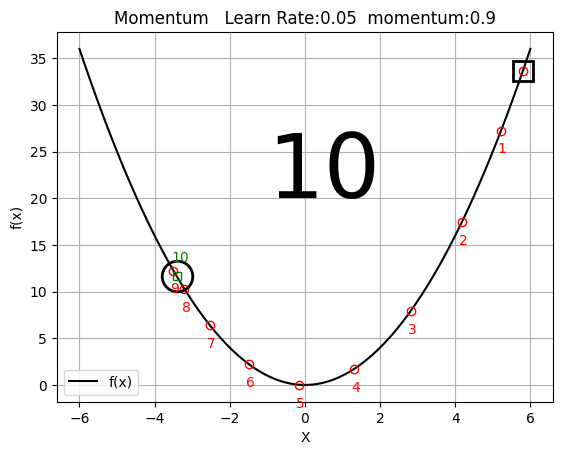

In [5]:
# Momentum -------------------------------------------- 2 <GrdientDescentT.ipynb>

START = 5.8                                            # x 시작 값
LEARNING_RATE = 0.05                                   # 학습율
EPOCHS = 10                                            # 학습 회수
MOMENTUM = 0.9                                         # 관성 값(작으면 마찰이 크게 작용)

x = START
velocity = 0                                           # Momentum 관성 계수 초기화

paths = [x,]                                           # x 위치 데이터
paths_velocity = [velocity,]                           # 관성 방향 데이터

print("="*41)
print('Ep.       x     f(x)         g   velocity')
print(f'    {x:8.5f} {func(x):8.5f}  {func(x):8.5f} {velocity:8.5f}')
print("-"*41)
# ==============================================================================
for epoch in range(EPOCHS):

  g = grad_func(x)
  velocity = MOMENTUM * velocity + LEARNING_RATE * g     # 속도 업데이트
  x = x - velocity                                       # 속도에 의한 위치 업데이트

  paths.append(x)
  paths_velocity.append(velocity)

  print(f'{epoch+1:2d}  {x:8.5f} {func(x):8.5f}  {grad_func(x):8.5f} {velocity:8.5f}')

graph(np.array(paths), 'Momentum',
      f'Learn Rate:{LEARNING_RATE}  momentum:{MOMENTUM}', direction = paths_velocity)

### 3. Nesterov Accelerated Gradient (NAG)

모멘텀의 한 종류로, '미리 본(look-ahead)' 방식으로 업데이트를 수행합니다. 현재 모멘텀이 가리키는 방향으로 먼저 이동해보고, 그 지점에서 기울기를 계산하여 업데이트에 반영합니다. 이는 오버슈팅을 줄이고 더 빠르고 안정적인 수렴을 가능하게 합니다.

$$ \theta_{look-ahead} =  \theta_{old} - \beta v_{old}$$
$$v_{new} = \beta v_{old} + \eta \nabla J(\theta_{look-ahead})$$
$$\theta_{new} = \theta_{old} - v_{new}$$
$$ $$
$$\eta:Learn~Rate$$


- **장점**: 모멘텀보다 더 안정적이고 빠른 수렴.
- **단점**: $\beta$ 값 조정 필요.

Ep.        x      f(x)   velocity x_look-ahead  g(x_look-ahead)
      5.80000  33.64000   0.00000    5.80000    11.60000
---------------------------------------------------------------
 1    5.22000  27.24840   0.58000    5.80000    11.60000
 2    4.22820  17.87768   0.99180    4.69800     9.39600
 3    3.00202   9.01214   1.22618    3.33558     6.67116
 4    1.70862   2.91937   1.29341    1.89846     3.79692
 5    0.49009   0.24019   1.21852    0.54455     1.08910
 6   -0.54592   0.29802   1.03601   -0.60657    -1.21315
 7   -1.33049   1.77021   0.78458   -1.47833    -2.95665
 8   -1.83295   3.35971   0.50246   -2.03661    -4.07323
 9   -2.05665   4.22980   0.22370   -2.28516    -4.57033
10   -2.03218   4.12974  -0.02447   -2.25797    -4.51595


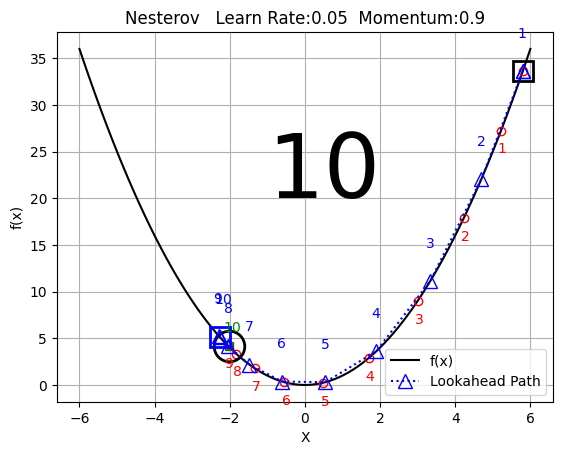

In [6]:
# Nesterov Accelerated Gradient (NAG) ----------------- 3 <GrdientDescentT.ipynb>

START = 5.8                                            # x 시작 값
LEARNING_RATE = 0.05                                   # 초기 학습율
EPOCHS = 10                                             # 학습 회수
MOMENTUM = 0.9                                         # 모멘텀 계수 x 의 관성

x = START
velocity = 0
x_look_ahead = x - MOMENTUM * velocity                 #
paths = [x,]                                           # Stores x_current values
lookahead_paths = [x,]                                 # Stores x_lookahead values
paths_v = [velocity,]

print("="*63)
print('Ep.        x      f(x)   velocity x_look-ahead  g(x_look-ahead)')
print(f'     {x:8.5f}  {func(x):8.5f}  {velocity:8.5f}',
        f'  {x_look_ahead:8.5f}    {grad_func(x_look_ahead):8.5f}')
print("-"*63)
# ==============================================================================
for epoch in range(EPOCHS):

  x_look_ahead = x - MOMENTUM * velocity               # 모멘텀을 적용한 미래 위치

  g_look_ahead = grad_func(x_look_ahead)                         # 미래 위치의 gradient
  velocity = MOMENTUM * velocity + LEARNING_RATE * g_look_ahead  # 속도 업데이트
  x = x - velocity

  lookahead_paths.append(x_look_ahead)                 # Store this x_lookahead
  paths.append(x)
  paths_v.append(velocity)

  print(f'{epoch+1:2d}   {x:8.5f}  {func(x):8.5f}  {velocity:8.5f}',
        f'  {x_look_ahead:8.5f}    {g_look_ahead:8.5f}')

graph(np.array(paths),'Nesterov', f'Learn Rate:{LEARNING_RATE}  Momentum:{MOMENTUM}',
       paths_lookahead=np.array(lookahead_paths), direction=paths_v)

### 4. AdaGrad (Adaptive Gradient)

각 파라미터마다 고유한 적응형 학습률을 적용하는 옵티마이저입니다. 자주 업데이트되는 파라미터는 학습률을 작게, 드물게 업데이트되는 파라미터는 학습률을 크게 조정합니다. 과거 기울기 제곱의 누적을 사용하여 학습률을 조정하며, 특히 희소한 데이터에 효과적입니다.

$$g = \nabla J(\theta_{old}) $$
$$\theta_{new} = \theta_{old} - \frac{\eta}{\sqrt{\Sigma g^2} + \epsilon} \cdot g$$
$$ $$
$$\eta:Learn~Rate$$

- **장점**: 각 파라미터에 대한 학습률 자동 조정, 희소한 데이터에 효과적.
- **단점**: 학습률이 지속적으로 감소하여 학습이 너무 일찍 멈출 수 있음.

Ep.      x     f(x)        g       g²     Σg²  eff_lr
    5.80000 33.64000 11.60000 134.56000  0.00000    -
----------------------------------------------------------
 1  5.30000 28.09000 11.60000 134.56000 134.56000  0.04310
 2  4.96271 24.62853 10.60000 112.36000 246.92000  0.03182
 3  4.69570 22.04959  9.92543 98.51414 345.43414  0.02690
 4  4.47020 19.98271  9.39140 88.19835 433.63249  0.02401
 5  4.27295 18.25807  8.94041 79.93084 513.56333  0.02206
 6  4.09652 16.78150  8.54589 73.03229 586.59562  0.02064
 7  3.93630 15.49447  8.19304 67.12598 653.72161  0.01956
 8  3.78916 14.35777  7.87260 61.97788 715.69949  0.01869
 9  3.65289 13.34360  7.57833 57.43106 773.13055  0.01798
10  3.52583 12.43146  7.30578 53.37439 826.50494  0.01739
11  3.40672 11.60572  7.05166 49.72584 876.23078  0.01689
12  3.29456 10.85414  6.81343 46.42287 922.65366  0.01646
13  3.18857 10.16695  6.58912 43.41656 966.07021  0.01609
14  3.08807  9.53619  6.37713 40.66779 1006.73800  0.01576
15  2.99254  8.955

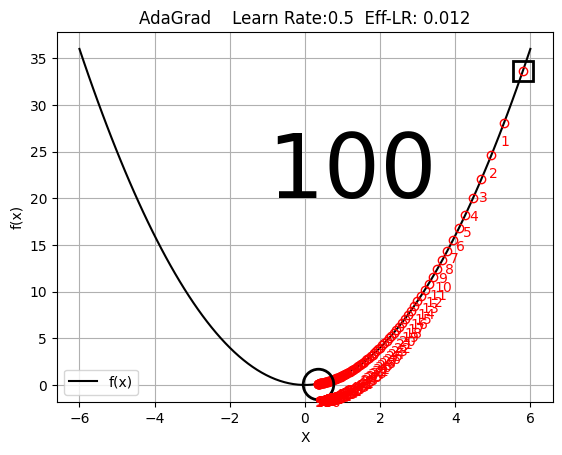

In [7]:
# Adagrad --------------------------------------------- 4 <GrdientDescentT.ipynb>

START = 5.8                   # 시작 위치
LEARNING_RATE = 0.5           # 초기 학습율
EPOCHS = 100                    # 학습 회수
epsilon = 1e-8                # 0으로 나누는 문제 방지 (분모가 0 이 되는 것 방지)

x = START

paths = [x,]

G = 0.0                                   # 기울기 제곱 누적값 초기화

print("="*58)
print('Ep.      x     f(x)        g       g²     Σg²  eff_lr')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f} {grad_func(x)**2:8.5f} {G:8.5f}',
     f'   -')
print("-"*58)

# ==============================================================================
for epoch in range(EPOCHS):

  g = grad_func(x)
  # 기울기 제곱 누적 -----------------------------------------------------------
  G = G + g**2                            # Σg^2
  # AdaGrad 업데이트 (적응형 학습률) -------------------------------------------
  eff_lr = LEARNING_RATE / np.sqrt(G + epsilon)
  x = x - eff_lr * g

  paths.append(x)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f}',
        f'{g:8.5f} {g**2:8.5f} {G:8.5f} {eff_lr:8.5f}')

graph(np.array(paths), 'AdaGrad', f' Learn Rate:{LEARNING_RATE}  Eff-LR:{eff_lr:6.3f}')

### 5. RMSprop (Root Mean Square Propagation)

Adagrad의 학습률 감소 문제를 해결하기 위해 고안되었습니다. 과거 기울기 제곱을 무한히 누적하는 대신, 지수 가중 이동 평균을 사용하여 최근 기울기 정보에 더 큰 가중치를 부여합니다. 이를 통해 학습률이 너무 빠르게 감소하는 것을 방지하고, 장기적인 학습에 더 유리합니다.
$$g = \nabla J(\theta_{old}) $$
$$v_{new} = \beta_2 v_{old} + (1 - \beta_2) g^2$$
$$\theta_{new} = \theta_{old} - \frac{\eta}{\sqrt{v_{new}} + \epsilon} \cdot g$$
$$ $$
$$\eta:Learn~Rate$$
$$\epsilon:1e-8$$

- **장점**: Adagrad의 학습률 감소 문제 해결, 희소한 기울기에 효과적, 안정적인 수렴.
- **단점**: 모멘텀 개념 부재.

Ep.      x     f(x)        g        g²    v     eff_lr
    5.80000 33.64000 11.60000 134.56000     -    -
------------------------------------------------------------
 1  4.21886 17.79879 11.60000 134.56000 13.45600  0.13631
 2  3.25679 10.60669  8.43772 71.19516 19.22992  0.11402
 3  2.55522  6.52916  6.51358 42.42676 21.54960  0.10771
 4  2.01053  4.04221  5.11045 26.11665 22.00631  0.10659
 5  1.57614  2.48422  4.02105 16.16885 21.42256  0.10803
 6  1.22609  1.50331  3.15228  9.93689 20.27399  0.11105
 7  0.94368  0.89053  2.45219  6.01324 18.84792  0.11517
 8  0.71692  0.51398  1.88735  3.56210 17.31934  0.12014
 9  0.53652  0.28785  1.43384  2.05591 15.79299  0.12582
10  0.39478  0.15585  1.07304  1.15142 14.32883  0.13209
11  0.28511  0.08129  0.78957  0.62342 12.95829  0.13890
12  0.20174  0.04070  0.57023  0.32516 11.69498  0.14621
13  0.13961  0.01949  0.40349  0.16280 10.54176  0.15400
14  0.09430  0.00889  0.27921  0.07796  9.49538  0.16226
15  0.06205  0.00385  0.18860  0.0

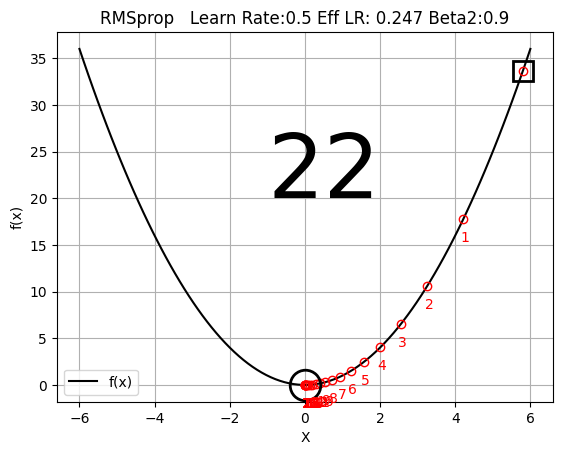

In [8]:
# RMSprop --------------------------------------------- 5 <GrdientDescentT.ipynb>

START = 5.8
LEARNING_RATE = 0.5                                 # 학습율
EPOCHS = 22                                         # 학습 회수

BETA2 = 0.9                                         # RMSprop의 감쇠율
EPSILON = 1e-8                                      # 0 으로 나누는 문제 방지
x = START

paths = [x,]

v = 0.0                            # Squared gradient accumulator (RMSprop 핵심)
print("="*60)
print('Ep.      x     f(x)        g        g²    v     eff_lr')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f} {grad_func(x)**2:8.5f}     -    -')
print("-"*60)
# ==============================================================================
for epoch in range(EPOCHS):

  g = grad_func(x)                              # x 에서 기울기 (미분)
  # RMSprop 업데이트 -----------------------------------------------------------
  v = BETA2 * v + (1 - BETA2) * (g**2)              # 학습율에 지수이동평균 적용
  eff_lr = LEARNING_RATE / (np.sqrt(v) + EPSILON)   # 실제 적용 학습율
  x = x - eff_lr * g

  paths.append(x)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g**2:8.5f} {v:8.5f} {eff_lr:8.5f}')

# 그래프 -----------------------------------------------------------------------
graph(np.array(paths), 'RMSprop',
      f'Learn Rate:{LEARNING_RATE} Eff LR:{eff_lr:6.3f} Beta2:{BETA2}')

### 6. Adam (Adaptive Moment Estimation)

모멘텀과 RMSprop의 장점을 결합한 가장 널리 사용되는 최적화 알고리즘 중 하나입니다. 기울기의 1차 모멘트(평균, 모멘텀)와 2차 모멘트(분산, RMSprop)의 지수 가중 이동 평균을 계산하고, 초기 단계의 편향을 보정하여 적응적으로 학습률을 조정합니다.

$$g = \nabla J(\theta_{old}) $$
$$m = \beta_1 m + (1 - \beta_1) g$$
$$v = \beta_2 v + (1 - \beta_2) g^2$$
$$\hat{m} = m / (1 - \beta_1^{t})$$
$$\hat{v} = v / (1 - \beta_2^{t})$$
$$\theta_{new} = \theta_{old} - \hat{m} \frac{\eta}{\sqrt{\hat{v}}+ \epsilon}$$
$$ $$
$$ t = time~step(1, 2, 3,~ ...)$$
$$\eta:Learn~Rate$$
- **장점**: 빠른 수렴, 구현 용이성, 다양한 문제에 강력한 성능.
- **단점**: Weight Decay 적용 방식에 따라 정규화 효과가 약해질 수 있음.

Ep.      x     f(x)      g        g²      m        v     m_hat     v_hat    eff_lr
    5.80000 33.64000 11.60000 134.56000    -        -       -         -        -
-------------------------------------------------------------------------------------
 1  5.30000 28.09000 11.60000 134.56000  1.16000  0.13456 11.60000 134.56000  0.04310
 2  4.80168 23.05613 10.60000 112.36000  2.10400  0.24679 11.07368 123.45445  0.04500
 3  4.30641 18.54518  9.60336 92.22450  2.85394  0.33876 10.53113 113.03405  0.04703
 4  3.81579 14.56025  8.61282 74.18072  3.42982  0.41261  9.97332 103.30613  0.04919
 5  3.33165 11.09991  7.63158 58.24101  3.85000  0.47043  9.40148 94.27507  0.05150
 6  2.85611  8.15734  6.66331 44.39966  4.13133  0.51436  8.81710 85.94169  0.05393
 7  2.39153  5.71942  5.71221 32.62937  4.28942  0.54648  8.22195 78.30277  0.05650
 8  1.94059  3.76588  4.78306 22.87767  4.33878  0.56881  7.61814 71.35034  0.05919
 9  1.50620  2.26864  3.88118 15.06352  4.29302  0.58330  7.00811 65.071

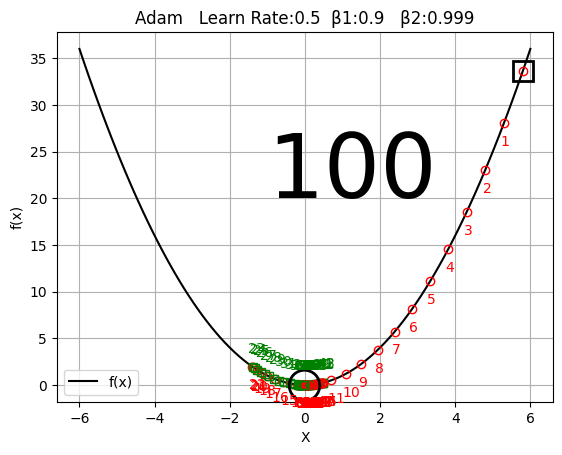

In [9]:
# Adam ------------------------------------------------ 6 <GrdientDescentT.ipynb>

START = 5.8                               # x 시작 값
LEARNING_RATE = 0.5                       # 초기 학습율
EPOCHS = 100 #55                               # 학습 회수

BETA1 = 0.9                               # 1 차 모멘트 계수, x 의 관성에 관여
BETA2 = 0.999                             # 2 차 모멘트 계수, 학습율에 관여
EPSILON = 1e-8

x= START
m = 0.0                                   # 일차 모멘트(Momentum 관성 계수) 초기화
v = 0.0                                   # 이차 모멘트(RMSProp 역할) 초기화

paths = [x, ]                             # x 위치 데이터
paths_m_hat = [m, ]                       # 관성 방향 데이터

print("="*85)
print('Ep.      x     f(x)      g        g²      m        v     m_hat     v_hat    eff_lr')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f} {grad_func(x)**2:8.5f}',
      f'   -        -       -         -        -')
print("-"*85)
# ==============================================================================
for epoch in range(EPOCHS):

  t = epoch + 1                                       # time step
  g = grad_func(x)                                    # x 에서 기울기 (미분)
  # Moment 업데이트 ------------------------------------------------------------
  m = BETA1 * m + ((1 - BETA1) * g)                   # 관성 지수이동평균
  v = BETA2 * v + ((1 - BETA2) * g**2)                # 학습율 지수이동평균
  # Bias Correction ------------------------------------------------------------
  m_hat = m / (1 - BETA1**t)
  v_hat = v / (1 - BETA2**t)
  # Adaptive Learning Rate -----------------------------------------------------
  eff_lr = LEARNING_RATE / (np.sqrt(v_hat) + EPSILON) # 실제 적용 학습율
  # Parameter Update -----------------------------------------------------------
  x = x - eff_lr * m_hat                              # Adam update

  paths.append(x)
  paths_m_hat.append(m_hat)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g**2:8.5f} {m:8.5f} {v:8.5f}',
        f'{m_hat:8.5f} {v_hat:8.5f} {eff_lr:8.5f}')

# 그래프 =======================================================================
graph(np.array(paths), 'Adam',
      f'Learn Rate:{LEARNING_RATE}  β1:{BETA1}   β2:{BETA2}',direction=paths_m_hat)

### 7. Nadam (Nesterov-accelerated Adaptive Moment Estimation)

Adam에 Nesterov Accelerated Gradient의 '미리 보기' 개념을 통합한 옵티마이저입니다. 모멘텀 항을 계산할 때 현재 기울기 대신 '미래의 기울기'를 사용하여 업데이트를 더욱 정확하고 빠르게 만듭니다.

$$g = \nabla J(\theta_{old}) $$
$$m = \beta_1 m + (1 - \beta_1) g$$
$$v = \beta_2 v + (1 - \beta_2) g^2$$
$$\hat{m} = \frac{m} {1 - \beta_1^t}$$
$$\hat{v} = \frac{v} {1 - \beta_2^t}$$
$$m_{nesterov} = \frac{\beta_1 \hat{m}_t + (1 - \beta_1) g }{1 - \beta_1^t}$$
$$\theta_{new} = \theta_{old} - m_{nesterov} \frac{\eta}{\sqrt{\hat{v} }+ \epsilon}$$

$$ $$
$$t=time~step(1, 2, 3,~ ...)$$
$$\eta:Learn~Rate$$
- **장점**: Adam보다 더 빠른 수렴과 안정적인 성능.
- **단점**: 더 복잡한 계산.

Ep.      x     f(x)        g       g²       m        v     m_hat   v_hat   m_nesterov eff_lr
    5.80000 33.64000 11.60000 134.56000      -        -       -        -       -       -
----------------------------------------------------------------------------------------------
 1  4.09000 16.72810 11.60000 134.56000  1.16000  0.13456 11.60000 134.56000 22.04000  0.07759
 2  2.91295  8.48529  8.18000 66.91240  1.86200  0.20134  9.80000 100.71928 13.12526  0.08968
 3  1.93232  3.73386  5.82590 33.94115  2.25839  0.23508  8.33354 78.43763  9.64997  0.10162
 4  1.08395  1.17495  3.86464 14.93543  2.41902  0.24978  7.03407 62.53825  7.45443  0.11381
 5  0.35382  0.12519  2.16790  4.69981  2.39390  0.25423  5.84578 50.94740  5.79059  0.12609
 6 -0.25698  0.06604  0.70763  0.50074  2.22528  0.25447  4.74919 42.51858  4.42530  0.13802
 7 -0.74402  0.55357 -0.51396  0.26415  1.95135  0.25448  3.74035 36.46410  3.26780  0.14904
 8 -1.10563  1.22242 -1.48804  2.21427  1.60741  0.25644  2.82234 32.

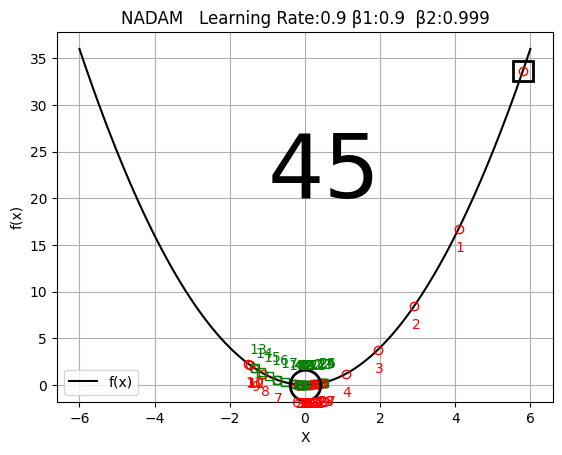

In [10]:
# Nadam (Nesterov-accelerated Adaptive Moment Estimation)-- 7 <GrdientDescentT.ipynb>

START = 5.8                               # x 시작 값
LEARNING_RATE = 0.9                       # 학습율
EPOCHS = 45                               # 학습 회수

BETA1 = 0.9                               # 1차 모멘트 감쇠율
BETA2 = 0.999                             # 2차 모멘트 감쇠율
EPSILON = 1e-8                            # 0으로 나누기 방지

x = START
m = 0                                     # 1차 모멘트 (기울기의 지수 이동 평균)
v = 0                                     # 2차 모멘트 (기울기 제곱의 지수 이동 평균)

paths = [x,]                              # x 위치 데이터
paths_m_hat = [m,]                        # 관성 방향 데이터

print("="*94)
print('Ep.      x     f(x)        g       g²       m        v     m_hat   v_hat',
      '  m_nesterov eff_lr')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f} {grad_func(x)**2:8.5f} ',
        f'    -        -       -        -       -       -')
print("-"*94)

# ==============================================================================
for epoch in range(EPOCHS):

  t = epoch + 1                           # Time Step
  f_val = func(x)                         # x 에서 y 값
  g = grad_func(x)                        # x 에서 기울기 (미분)
  # 1차 및 2차 모멘트 업데이트 -------------------------------------------------
  m = BETA1 * m + (1 - BETA1) * g
  v = BETA2 * v + (1 - BETA2) * g**2
  # 편향 보정 (Bias correction) ------------------------------------------------
  m_hat = m / (1 - BETA1**t)
  v_hat = v / (1 - BETA2**t)
  # Nesterov momentum 적용 -----------------------------------------------------
  m_nesterov = BETA1 * m_hat + (1 - BETA1) * g / (1 - BETA1**t)
  # Effective learning rate 계산 -----------------------------------------------
  eff_lr = LEARNING_RATE / (np.sqrt(v_hat) + EPSILON)    # 실제 적용 학습율
  # 파라미터 업데이트 ----------------------------------------------------------
  x = x - eff_lr * m_nesterov

  paths.append(x)
  paths_m_hat.append(m_hat)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g**2:8.5f}',
        f'{m:8.5f} {v:8.5f} {m_hat:8.5f} {v_hat:8.5f} {m_nesterov:8.5f} {eff_lr:8.5f}')

graph(np.array(paths), 'NADAM',
      f'Learning Rate:{LEARNING_RATE} β1:{BETA1}  β2:{BETA2}', direction=paths_m_hat)

### 8. AdamW (Adam with decoupled Weight decay)

Adam의 Weight Decay 적용 방식에 대한 개선 버전입니다. 기존 Adam에서는 L2 정규화(Weight Decay)를 기울기에 직접 추가했지만, AdamW는 Weight Decay를 파라미터 업데이트와 '분리(decoupled)'하여 적용합니다. 이는 정규화 효과를 더욱 일관되고 강력하게 만들어 과적합 방지 및 일반화 성능 향상에 기여합니다.

$$g = \nabla J(\theta_{old}) $$
$$m = \beta_1 m + (1 - \beta_1) g$$
$$v = \beta_2 v + (1 - \beta_2) g^2$$
$$\hat{m} = \frac{m} {1 - \beta_1^t}$$
$$\hat{v} = \frac{v}{1 - \beta_2^t}$$
$$\theta_{new}=\theta_{old} - \hat m \cdot \frac{\eta}{\sqrt {\hat v } +\epsilon}-\eta \cdot \lambda \cdot \theta_{old}  $$

$$ $$
$$t=time~step(1, 2, 3,~ ...)$$
$$\eta:Learn~Rate$$
$$\lambda:Weight~Decay$$
- **장점**: Adam보다 뛰어난 일반화 성능, 효과적인 과적합 방지, 대형 모델 학습에 유리.
- **단점**: 추가적인 하이퍼파라미터(Weight Decay) 튜닝 필요.

Ep.      x     f(x)       g        g²      m        v     m_hat    v_hat    eff_lr w(W-D Adj)
    5.80000 33.64000 11.60000 134.56000     -        -       -        -        -       -
----------------------------------------------------------------------------------------------
 1  4.84780 23.50116 11.60000 134.56000  1.16000  0.13456 11.60000 134.56000  0.07759  0.04363
 2  3.91193 15.30317  9.69560 94.00466  2.01356  0.22843 10.59768 114.27219  0.08419  0.03521
 3  2.99987  8.99922  7.82385 61.21268  2.59459  0.28941  9.57413 96.56799  0.09159  0.02700
 4  2.12151  4.50079  5.99974 35.99687  2.93510  0.32512  8.53476 81.40247  0.09975  0.01909
 5  1.28946  1.66271  4.24301 18.00317  3.06590  0.34280  7.48674 68.69723  0.10859  0.01161
 6  0.51904  0.26940  2.57892  6.65083  3.01720  0.34911  6.43931 58.33028  0.11784  0.00467
 7 -0.17258  0.02978  1.03808  1.07762  2.81929  0.34984  5.40401 50.12676  0.12712 -0.00155
 8 -0.76827  0.59024 -0.34515  0.11913  2.50284  0.34961  4.39455 43

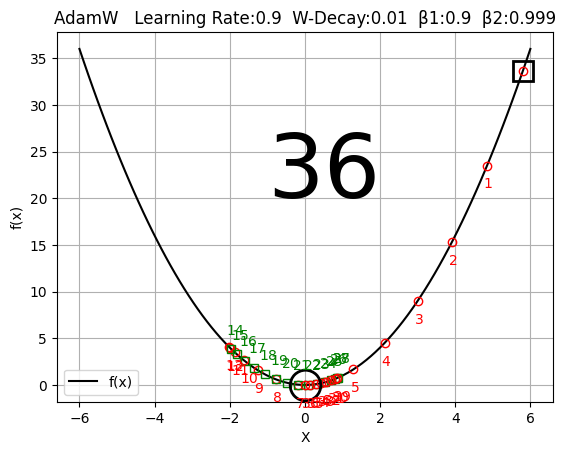

In [11]:
# ADAMW                                                8 <GrdientDescentT.ipynb>

START = 5.8                                         # 시작 X
LEARNING_RATE = 0.9                                 # 학습율
EPOCHS = 36                                        # 학습 회수

# AdamW parameters
BETA1 = 0.9
BETA2 = 0.999
EPSILON = 1e-8
WEIGHT_DECAY = 0.01 # Added weight decay for AdamW

m = 0
v = 0
x = START

paths = [x,]
paths_m_hat = [m,]

print("="*94)
print('Ep.      x     f(x)       g        g²      m        v     m_hat    v_hat',
      '   eff_lr w(W-D Adj)')
print(f'   {x:8.5f} {func(x):8.5f} {grad_func(x):8.5f} {grad_func(x)**2:8.5f}',
        '    -        -       -        -        -       -')
print("-"*94)
# ==============================================================================
for epoch in range(EPOCHS):

  t = epoch + 1                         # time step
  g = grad_func(x)                      # Gradient
  # Update biased first and second moment estimates
  m = BETA1 * m + (1 - BETA1) * g       # 1차 모멘트 (관성에 지수이동평균 적용)
  v = BETA2 * v + (1 - BETA2) * g**2    # 2차 모멘트 (학습율에 지수이동평균 적용)
  # Bias correction
  m_hat = m / (1 - BETA1**t)
  v_hat = v / (1 - BETA2**t)
  # Adaptive Learning Rate -----------------------------------------------------
  eff_lr = LEARNING_RATE / (np.sqrt(v_hat) + EPSILON)       # 실제 적용 학습율
  w = LEARNING_RATE * WEIGHT_DECAY * x
  # Parameter Update, Decoupled weight decay (AdamW) ---------------------------
  x = x -  m_hat*eff_lr - w

  paths.append(x)
  paths_m_hat.append(m_hat)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g*g:8.5f} {m:8.5f} {v:8.5f}',
        f'{m_hat:8.5f} {v_hat:8.5f} {eff_lr:8.5f} {LEARNING_RATE * WEIGHT_DECAY * x:8.5f}')

graph(np.array(paths), 'AdamW', # Changed optimizer name
      f'Learning Rate:{LEARNING_RATE}  W-Decay:{WEIGHT_DECAY}  β1:{BETA1}  β2:{BETA2}',
      direction=paths_m_hat)

### 9. NAdamW (NAdam + AdamW 결합)

Nadam과 AdamW의 장점을 결합한 옵티마이저입니다. Nesterov의 '미리 보기' 모멘텀으로 빠른 수렴을 유도하고, decoupled Weight Decay를 통해 강력한 정규화 효과와 일반화 성능을 동시에 얻습니다.

$$g = \nabla J(\theta_{old}) $$
$$m = \beta_1 m + (1 - \beta_1) g$$
$$v = \beta_2 v + (1 - \beta_2) g^2$$
$$\hat{m} = \frac{m} {1 - \beta_1^t}$$
$$\hat{v} = \frac{v}{1 - \beta_2^t}$$

$$m_{nesterov} = \beta_1 \hat{m} + \frac{(1 - \beta_1) g} {(1 - \beta_1^t)}$$

$$\theta_{new} = \theta_{old} - m_{nesterov}\frac{\eta }{\sqrt{\hat{v}_t} + \epsilon} - \eta \lambda \theta_{old}$$
$$ $$
$$t=time~step(1, 2, 3,~ ...)$$
$$\eta:Learn~Rate$$
$$\lambda:Weight~Decay$$


- **장점**: Nadam의 빠른 수렴 + AdamW의 뛰어난 일반화 성능 및 과적합 방지.


Ep.     x      f(x)       g       g²       m        v      m_hat   v_hat m_nesterov eff_lr w(W-D Adj)
36  5.80000 33.64000  0.28324  0.08023      -        -       -       -         -        -        - 
-------------------------------------------------------------------------------------------------------
 1  4.03780 16.30383 11.60000 134.56000  1.16000  0.13456 11.60000 134.56000 22.04000  0.07759  0.05220
 2  2.82882  8.00223  8.07560 65.21532  1.85156  0.19964  9.74505 99.87031 13.02086  0.09006  0.03634
 3  1.83035  3.35019  5.65764 32.00892  2.23217  0.23145  8.23678 77.22721  9.50080  0.10241  0.02546
 4  0.97667  0.95389  3.66070 13.40075  2.37502  0.24462  6.90614 61.24664  7.27999  0.11500  0.01647
 5  0.25273  0.06387  1.95335  3.81556  2.33285  0.24819  5.69670 49.73743  5.60402  0.12761  0.00879
 6 -0.34181  0.11683  0.50545  0.25548  2.15011  0.24820  4.58878 41.46980  4.23778  0.13976  0.00227
 7 -0.80476  0.64764 -0.68362  0.46734  1.86674  0.24842  3.57817 35.59471  3.08

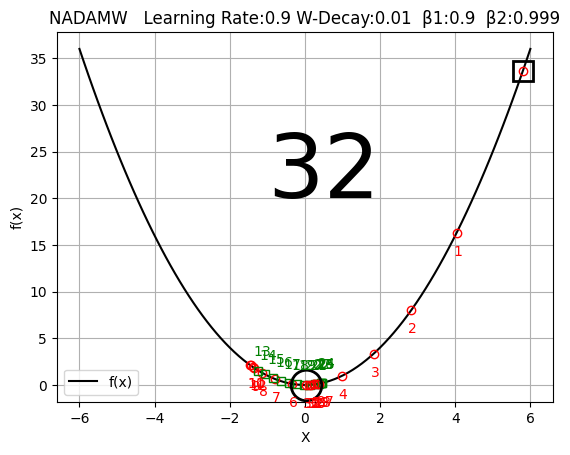

In [12]:
# NAdamW                                                9 <GrdientDescentT.ipynb>

START = 5.8                               # x 시작 값
LEARNING_RATE = 0.9                       # 학습율
EPOCHS = 32                               # 학습 회수

BETA1 = 0.9                               # 1차 모멘트 감쇠율
BETA2 = 0.999                             # 2차 모멘트 감쇠율
EPSILON = 1e-8                            # 0으로 나누기 방지
WEIGHT_DECAY = 0.01                       # Added weight decay for NadamW

x = START
m = 0                                     # 1차 모멘트 (기울기의 지수 이동 평균)
v = 0                                     # 2차 모멘트 (기울기 제곱의 지수 이동 평균)

paths = [x, ]                             # x 위치 데이터
paths_m_hat = [m, ]                       # 관성 방향 데이터

print("="*103)
print('Ep.     x      f(x)       g       g²       m        v      m_hat   v_hat',
      'm_nesterov eff_lr w(W-D Adj)')
print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g**2:8.5f}',
        f'     -        -       -       -         -        -        - ')
print("-"*103)
# ==============================================================================
for epoch in range(EPOCHS):

  t = epoch +  1                      # time step
  g = grad_func(x)                    # x 에서 기울기 (미분)
  # 1차 및 2차 모멘트 업데이트 -------------------------------------------------
  m = BETA1 * m + (1 - BETA1) * g
  v = BETA2 * v + (1 - BETA2) * g**2
  # 편향 보정 (Bias correction) ------------------------------------------------
  m_hat = m / (1 - BETA1**t)
  v_hat = v / (1 - BETA2**t)
  # Nesterov momentum 적용 -----------------------------------------------------
  m_nesterov = BETA1 * m_hat + (1 - BETA1) * g / (1 - BETA1**t)
  # Effective learning rate, Weight Decay --------------------------------------
  eff_lr = LEARNING_RATE / (np.sqrt(v_hat) + EPSILON)
  w = LEARNING_RATE * WEIGHT_DECAY * x
  # 파라미터 업데이트 (NadamW) -------------------------------------------------
  x = x - m_nesterov * eff_lr - w

  paths.append(x)
  paths_m_hat.append(m_hat)
  # 출력 -----------------------------------------------------------------------
  print(f'{epoch+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f} {g**2:8.5f}',
        f'{m:8.5f} {v:8.5f} {m_hat:8.5f} {v_hat:8.5f}',
        f'{m_nesterov:8.5f} {eff_lr:8.5f} {w:8.5f}')

graph(np.array(paths), 'NADAMW',
      f'Learning Rate:{LEARNING_RATE} W-Decay:{WEIGHT_DECAY}  β1:{BETA1}  β2:{BETA2}',
      direction=paths_m_hat)